In [2]:
import sys
print(sys.executable)

C:\Users\USER\AppData\Local\Programs\Python\Python313\python.exe


```markdown
# 01 - Exploratory Data Analysis

Goal: Understand the Telco Customer Churn dataset, identify data quality issues, and explore patterns that signal WHY customers leave.
```







In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all charts
sns.set_style("whitegrid")

# Load the raw dataset
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check data types
print(df.dtypes)
print(f"\nMissing values:\n{df.isnull().sum().sum()} total NaN values")



customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
0 total NaN values


In [3]:
# The real issue: TotalCharges has blank strings instead of NaN and its an obj instead of int
blanks = df[df["TotalCharges"] == " "]
print(f"\nRows with blank TotalCharges: {len(blanks)}")




Rows with blank TotalCharges: 11


## Data Quality Notes

- **TotalCharges** contains 11 blank strings (not NaN) for customers with 0 tenure.
- These will need conversion to numeric in the preprocessing step.
- No other missing values detected.

In [4]:
# Visualize target variable distribution (class imbalance check)
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print(f"\nChurn rate: {churn_counts['Yes'] / len(df) * 100:.1f}%")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.5%


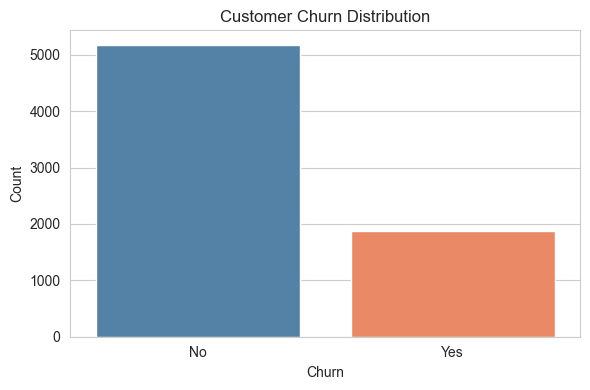

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", palette=["steelblue", "coral"], hue = 'Churn' )
plt.title("Customer Churn Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [10]:

# Churn rate by contract type - month-to-month vs locked-in contracts
contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack()
contract_churn.head()

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


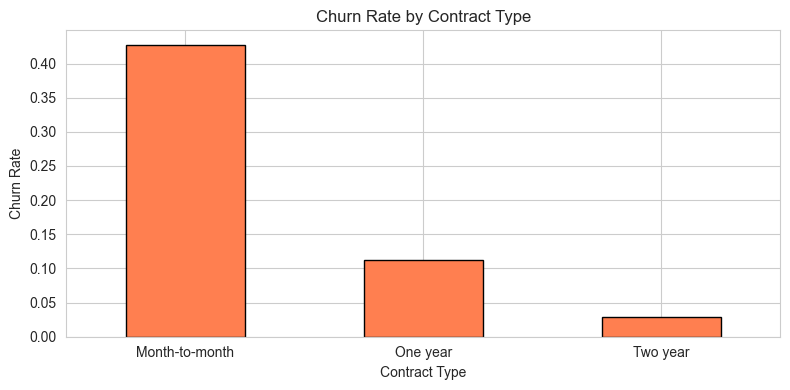

In [12]:
contract_churn["Yes"].plot(kind="bar", figsize=(8, 4), color="coral", edgecolor="black")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


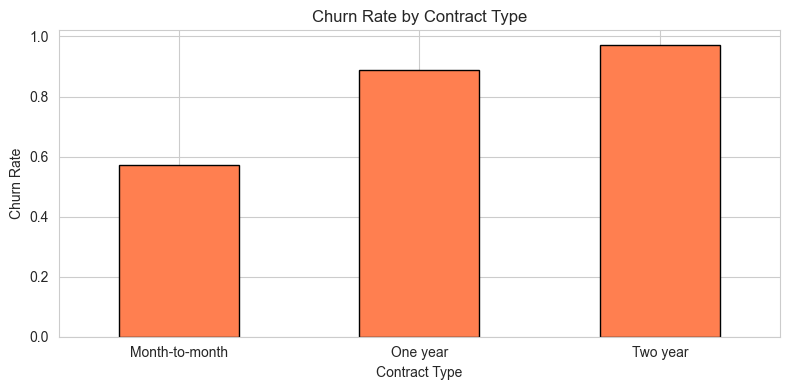

In [14]:
contract_churn["No"].plot(kind="bar", figsize=(8, 4), color="coral", edgecolor="black")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### OBS
#### Month-to-month customers churn at a dramatically higher rate than those on one-year or two-year contracts. This makes business sense. Customers without commitment have no switching cost.

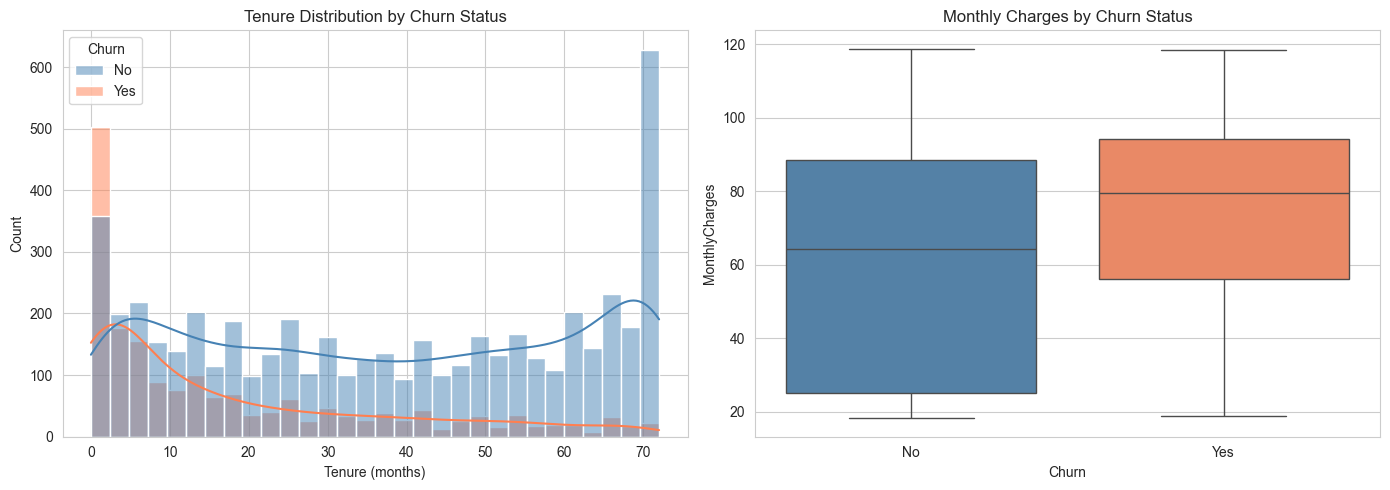

In [16]:
# Tenure distribution and monthly charges by churn status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Tenure histogram split by churn
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, ax=axes[0],
             palette=["steelblue", "coral"])
axes[0].set_title("Tenure Distribution by Churn Status")
axes[0].set_xlabel("Tenure (months)")

# Right: Monthly charges boxplot split by churn
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["steelblue", "coral"],hue ='Churn' ,
            ax=axes[1])
axes[1].set_title("Monthly Charges by Churn Status")

plt.tight_layout()
plt.show()

#### The tenure histogram shows that customers who churn are heavily concentrated in the first few months. Long-tenure customers rarely leave.

#### The monthly charges boxplot shows churners tend to pay more per month. Customers on premium plans without long-term contracts are the highest flight risk.

## Key EDA Findings: Why Customers Leave

1. **Class imbalance**: ~27% churn rate means we need resampling or class weights during modeling.
2. **Contract type is a strong signal**: Month-to-month customers churn at 3-4x the rate of locked-in contracts.
3. **Tenure matters**: Most churn happens in the first 1-12 months. Long-tenure customers are loyal.
4. **Higher charges correlate with churn**: Customers paying more monthly are more likely to leave, possibly because they have more alternatives or feel less value.

**Business implication**: A retention team should target new, month-to-month customers with high monthly charges. These are the highest-risk group.